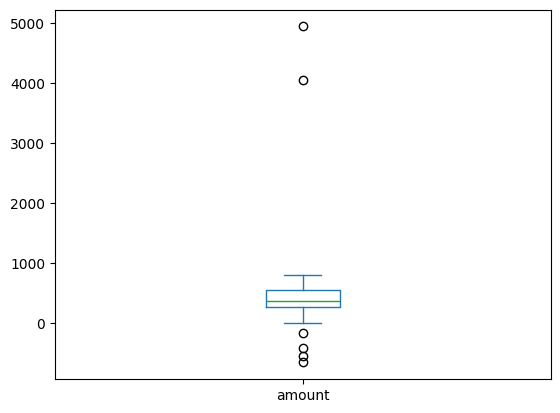

0


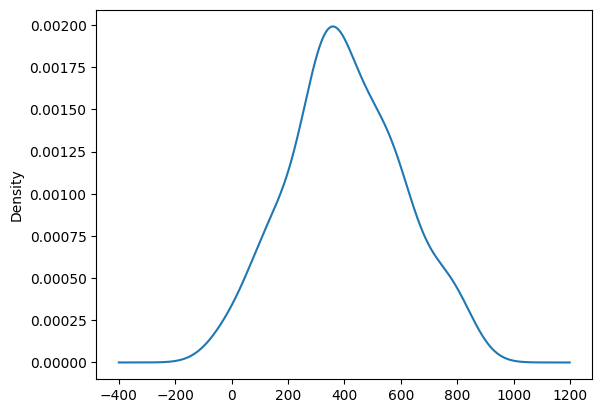

<class 'pandas.core.frame.DataFrame'>
Index: 81 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sale_id      81 non-null     object 
 1   salesperson  78 non-null     object 
 2   region       81 non-null     object 
 3   sale_date    81 non-null     object 
 4   amount       81 non-null     float64
dtypes: float64(1), object(4)
memory usage: 3.8+ KB


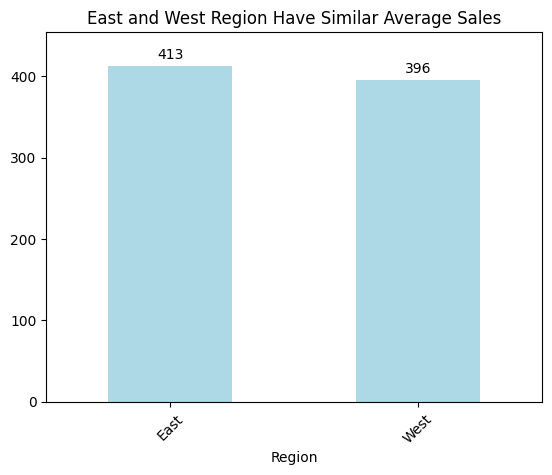

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Exercise 1
# Load the CSV and check for missing values — how many, and in which columns?
df = pd.read_csv('messy_store_data.csv')

# Exercise 2
# Check for and remove any exact duplicate rows.

# get number of duplicates
df.duplicated().sum()

# remove duplicates
df = df.drop_duplicates(keep='first', ignore_index =True)

# check for duplicates removed
df.duplicated().sum()

# Exercise 3
# Decide how to handle the missing values in "amount" (drop vs impute) and
# missing values in "salesperson" (drop vs flag as "Unknown"). Justify your
# choice in a comment, then apply it.

nulls = df[df.isnull().any(axis=1)]
nulls

# Nans are found in salesperson and amount
# since we ae looking for information on sales by region
# we can save some rows by dropping the saleaperson column 
# from this analysis since it contains data aggrigations we don't need
# amounts will have to be dropped. We are looking for real number aggrigations
# of the amount of sales by region so imputing here will likely skew the data 
# centrally by most methods perhaps if we were building a ml model that would
# help it generalize better but here it will cloud our data

# dropping amount null for now leaving  salesperson column till the end so I can 
# clean it for practace

# dropping amount nulls
df = df[df['amount'].notnull()] 

# checking remaining nulls
nulls = df[df.isnull().any(axis=1)]


# Exercise 3.5 
# inspect each column clean and prepare data in each column for analysis 

# get column names and variable types
#df.info()

# 'sale_id'

# test for unique sales ID
len(df) - df.duplicated().sum() == len(df)

# Changing to object data type
df['sale_id'] = df.sale_id.astype('object')

# 'salesperson'

# check values
df.salesperson.value_counts()

# remove white space
df['salesperson'] = df['salesperson'].str.strip()

# check changes
df.salesperson.value_counts()

# 'region'

# check values
df.region.value_counts()
# remove white space and lowercase
df['region'] = df['region'].str.strip().str.capitalize()

# check changes
df.region.value_counts()

# dropping central region values
# 5 is not enough points to draw general conclusions from for the central region nd will not significantly sway the data either way

# drop all regions that are not East/West
df = df[df.region.isin(['East', 'West'])]

# check values
df.region.value_counts()

# 'sale_date'

# view data 
df.sale_date.value_counts

# convert to datatime and staderdize y/m/d
df['sale_date'] = pd.to_datetime(df['sale_date'], format='mixed', errors='coerce').dt.strftime('%Y-%m-%d')

# check values 
df.sale_date.value_counts()

# 'amount'

# contains large outliers
df['amount'].plot.box()
plt.show()

# showing outlier lines
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['amount'] < lower_bound) | (df['amount'] > upper_bound)]
outliers

# removing outliers  
df = df[(df['amount'] >= lower_bound) & (df['amount'] <= upper_bound)]
print(((df['amount'] < lower_bound) | (df['amount'] > upper_bound)).sum())

# seems normally distributed enough
df['amount'].plot.density()
plt.show()

df.info()

# Exercise 4
# Use describe() and a boxplot (or IQR calculation) on "amount" to identify
# any outliers. Investigate the one you find — is it a data entry error or
# a legitimate value?

# code is done as part of 3.5. I decided to drop the the negative amount numbers 
# as they are redicules in a data frame containing sales amounts which shuld not 
# ever be negative. I also dropped the high number using 1.5 times the IRQ as a cutoff.
# In practice I would consult further reaserch or the stakeholder as to whether sales
# typically showed this level of variability before choosing a cutoff number.

# Exercise 5
# Check for consistency issues: are all "region" values valid (East/West only)?
# Are all "sale_date" values parseable as dates and within a reasonable range?

# code is done as part of 3.5 
# dropped central region do to lack of sample size
# would consider imputing the region based on the sales agent
# becouse they don't typically sale accross regions ut this would be a
# research / ask the stakeholde question till then I will cut them
# 5 lines is a small impact on the data at any rate

# Exercise 6
# Produce one summary visualization (histogram or boxplot) of "amount" after
# cleaning, and one groupby summary (mean amount by region) to sanity-check
# the cleaned data makes sense.

# data with the nulls have thier regions intact I think I can to the aggrication without directally dropping the column
nulls = df[df.isnull().any(axis=1)]
nulls

region_totals = df.groupby('region')['amount'].mean().round(0).astype(int)
ax = region_totals.plot.bar(color='lightblue')
ax.margins(y=0.1)
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=45)
ax.set_xlabel('Region')
ax.set_title('East and West Region Have Similar Average Sales')
plt.show()

# Thought about adding a t-test but decided against because the averages were simmiler giving no need to prove how seperate they are
# you asked for a sanity test but I think this chart is good enough to present is there anything you would change to up its presentability?

In [46]:





# Exercise 4
# Use describe() and a boxplot (or IQR calculation) on "amount" to identify
# any outliers. Investigate the one you find — is it a data entry error or
# a legitimate value?

# Exercise 5
# Check for consistency issues: are all "region" values valid (East/West only)?
# Are all "sale_date" values parseable as dates and within a reasonable range?

# Exercise 6
# Produce one summary visualization (histogram or boxplot) of "amount" after
# cleaning, and one groupby summary (mean amount by region) to sanity-check
# the cleaned data makes sense.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sale_id      103 non-null    int64  
 1   salesperson  98 non-null     object 
 2   region       103 non-null    object 
 3   sale_date    103 non-null    object 
 4   amount       94 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sale_id      103 non-null    int64  
 1   salesperson  98 non-null     object 
 2   region       103 non-null    object 
 3   sale_date    103 non-null    object 
 4   amount       94 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.1+ KB


In [33]:
df.duplicated().sum()


np.int64(3)

In [35]:
df_no_dupe[['sale_id']].nunique(axis=1).sum()

np.int64(100)

In [37]:
df[['sale_id']].nunique(axis=1).value_counts()

1    103
Name: count, dtype: int64

In [42]:
df_no_dupe['sale_id'].nunique() == len(df_no_dupe['sale_id'])

True

In [37]:
print(((df['amount'] < lower_bound) | (df['amount'] > upper_bound)).sum())

0
